# Partie III : RNN, LSTM, GRU et Seq2Seq
**Module : Deep Learning — EMSI Casablanca**
**Annee universitaire 2025-2026**

---

## Vue d ensemble

Cette partie traite de la modelisation de sequences avec des architectures recurrentes.
On va travailler sur de la **traduction automatique anglais-allemand** avec le dataset **Multi30k**
(29 000 paires de phrases paralleles).

On va implementer et comparer RNN, LSTM et GRU dans un systeme Seq2Seq avec encodeur-decodeur,
tester le BPTT et le gradient clipping, comparer le decodage glouton et le beam search,
et evaluer avec la perplexite et le BLEU.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random
import math
import time
import urllib.request
import gzip
import io
import matplotlib.pyplot as plt
from collections import Counter

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilise : {device}")
print(f"PyTorch version : {torch.__version__}")


Device utilise : cuda
PyTorch version : 2.10.0+cu128


## 1. Theorie : Modele de Langage et Perplexite

### 1.1 Objectif probabiliste

un modele de langage ca sert a calculer la probabilite d une sequence de mots. par exemple si on a la phrase w1, w2, ..., wT on veut savoir a quel point cette sequence est probable.

pour faire ca on utilise la regle de chaine qui dit que :

P(w1, w2, ..., wT) = P(w1) x P(w2|w1) x P(w3|w1,w2) x ... x P(wT|w1,...,wT-1)

en gros ca veut dire qu a chaque etape on predit le mot suivant en fonction de tous les mots precedents. c est exactement ce que fait un RNN avec son etat cache ht.

### 1.2 La Perplexite

la perplexite c est la metrique qu on utilise pour savoir si notre modele est bon ou pas. la formule c est :

PPL = exp( -(1/T) * somme( log P(wt | w1...wt-1) ) )

pour l interpreter c est simple : si la perplexite vaut K ca veut dire que le modele est aussi perdu que quelqu un qui choisit au hasard entre K mots. donc plus c est petit mieux c est.

PPL = 1 c est le modele parfait, PPL = taille du vocabulaire c est un modele completement aleatoire, et entre les deux ca depend de la qualite du modele.

In [2]:
print("Illustration de la perplexite :")
print()
vocab_size = 10000
for ppl in [1, 10, 50, 100, vocab_size]:
    meaning = "parfait" if ppl == 1 else ("aleatoire" if ppl == vocab_size else "bon" if ppl < 30 else "moyen")
    print(f"  PPL = {ppl:6d}  -> {meaning}")


Illustration de la perplexite :

  PPL =      1  -> parfait
  PPL =     10  -> bon
  PPL =     50  -> moyen
  PPL =    100  -> moyen
  PPL =  10000  -> aleatoire


---
## 2. Preparation des Donnees : Dataset Multi30k

Le **Multi30k** est un dataset de traduction anglais-allemand avec 29 000 paires de phrases
tirees de descriptions d images Flickr. C est un vrai benchmark utilise en NLP.

On va le telecharger directement depuis le repo officiel sur GitHub.


In [3]:
import gzip, urllib.request

def download_and_read(url):
    data = urllib.request.urlopen(url, timeout=30).read()
    with gzip.open(io.BytesIO(data), 'rt', encoding='utf-8') as f:
        return [line.strip() for line in f.readlines()]

base = "https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/"
print("Telechargement du dataset Multi30k ...")

en_train = download_and_read(base + "train.en.gz")
de_train = download_and_read(base + "train.de.gz")
en_val   = download_and_read(base + "val.en.gz")
de_val   = download_and_read(base + "val.de.gz")

print(f"Train : {len(en_train)} paires")
print(f"Val   : {len(en_val)} paires")
print()
print("Exemples :")
for i in range(3):
    print(f"  EN : {en_train[i]}")
    print(f"  DE : {de_train[i]}")
    print()


Telechargement du dataset Multi30k ...
Train : 29000 paires
Val   : 1014 paires

Exemples :
  EN : Two young, White males are outside near many bushes.
  DE : Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.

  EN : Several men in hard hats are operating a giant pulley system.
  DE : Mehrere Männer mit Schutzhelmen bedienen ein Antriebsradsystem.

  EN : A little girl climbing into a wooden playhouse.
  DE : Ein kleines Mädchen klettert in ein Spielhaus aus Holz.



In [4]:
MAX_LEN   = 20
MAX_VOCAB = 5000
SOS, EOS, PAD, UNK = "<SOS>", "<EOS>", "<PAD>", "<UNK>"
SPECIAL = [PAD, SOS, EOS, UNK]

def simple_tokenize(sentence):
    import re
    sentence = sentence.lower().strip()
    sentence = re.sub(r"[^a-zA-Z0-9äöüÄÖÜß ]", " ", sentence)
    return sentence.split()

def build_vocab(sentences, max_vocab=MAX_VOCAB):
    counter = Counter()
    for s in sentences:
        counter.update(simple_tokenize(s))
    vocab = {tok: idx for idx, tok in enumerate(SPECIAL)}
    for word, _ in counter.most_common(max_vocab - len(SPECIAL)):
        if word not in vocab:
            vocab[word] = len(vocab)
    idx2word = {v: k for k, v in vocab.items()}
    return vocab, idx2word

src_vocab, src_idx2word = build_vocab(en_train)
tgt_vocab, tgt_idx2word = build_vocab(de_train)

print(f"Vocabulaire source (EN) : {len(src_vocab)} mots")
print(f"Vocabulaire cible  (DE) : {len(tgt_vocab)} mots")

def sentence_to_ids(sentence, vocab, max_len=MAX_LEN):
    tokens = simple_tokenize(sentence)[:max_len]
    return [vocab.get(t, vocab[UNK]) for t in tokens]

def ids_to_sentence(ids, idx2word):
    words = []
    for i in ids:
        w = idx2word.get(i, UNK)
        if w in (EOS, PAD):
            break
        if w != SOS:
            words.append(w)
    return " ".join(words)


Vocabulaire source (EN) : 5000 mots
Vocabulaire cible  (DE) : 5000 mots


In [5]:
class TranslationDataset(Dataset):
    def __init__(self, src_sents, tgt_sents, src_vocab, tgt_vocab, max_len=MAX_LEN):
        self.data = []
        for src, tgt in zip(src_sents, tgt_sents):
            src_ids = sentence_to_ids(src, src_vocab, max_len)
            tgt_ids = [tgt_vocab[SOS]] + sentence_to_ids(tgt, tgt_vocab, max_len) + [tgt_vocab[EOS]]
            if len(src_ids) > 1 and len(tgt_ids) > 2:
                self.data.append((src_ids, tgt_ids))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    max_src = max(len(s) for s in src_batch)
    max_tgt = max(len(t) for t in tgt_batch)
    src_padded = torch.zeros(len(src_batch), max_src, dtype=torch.long)
    tgt_padded = torch.zeros(len(tgt_batch), max_tgt, dtype=torch.long)
    for i, (s, t) in enumerate(zip(src_batch, tgt_batch)):
        src_padded[i, :len(s)] = torch.tensor(s)
        tgt_padded[i, :len(t)] = torch.tensor(t)
    return src_padded, tgt_padded

train_dataset = TranslationDataset(en_train, de_train, src_vocab, tgt_vocab)
val_dataset   = TranslationDataset(en_val,   de_val,   src_vocab, tgt_vocab)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=128, shuffle=False, collate_fn=collate_fn)

print(f"Train dataset : {len(train_dataset)} paires valides")
print(f"Val dataset   : {len(val_dataset)} paires valides")
print(f"Batches train : {len(train_loader)}")


Train dataset : 28998 paires valides
Val dataset   : 1014 paires valides
Batches train : 227



## 3. Architecture Seq2Seq : Encodeur-Decodeur

### Principe

L architecture **encodeur-decodeur** resout le probleme de la traduction ou la longueur
de la sequence de sortie peut differer de celle de l entree.

**Encodeur** : lit toute la phrase source et compresse l information dans un vecteur de contexte
(le dernier etat cache $h_T$).

**Decodeur** : part de ce vecteur de contexte et genere la traduction token par token.

### Teacher Forcing

Pendant l entrainement, au lieu de donner au decodeur sa propre prediction du token precedent
(qui peut etre fausse), on lui donne le **vrai token de reference**. Ca s appelle le teacher forcing.
Cela accelere la convergence mais peut creer un decalage entre entrainement et inference.

Dans notre implementation on utilise un ratio de 0.5 : la moitie du temps on donne le vrai token,
l autre moitie on donne la prediction du modele.

### BPTT et Gradient Clipping

Le BPTT (BackPropagation Through Time) remonte le gradient a travers toutes les etapes de la sequence.
Deux problemes connus :

**Gradient qui disparait** : multiplication repetee de valeurs < 1 → gradient ≈ 0 pour les premiers tokens.
Solution : LSTM / GRU avec leurs mecanismes de portes.

**Gradient qui explose** : multiplication repetee de valeurs > 1 → gradient tres grand.
Solution : **gradient clipping** — on borne la norme du gradient a `max_norm` :
$$\text{grad} \leftarrow \text{grad} \times \frac{\text{max\_norm}}{\|\text{grad}\|}$$


In [6]:
EMBED_DIM  = 128
HIDDEN_DIM = 256
N_LAYERS   = 2
DROPOUT    = 0.3

class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, cell_type, dropout):
        super().__init__()
        self.cell_type = cell_type
        self.n_layers  = n_layers
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout   = nn.Dropout(dropout)
        rnn_cls = {'rnn': nn.RNN, 'lstm': nn.LSTM, 'gru': nn.GRU}[cell_type]
        self.rnn = rnn_cls(embed_dim, hidden_dim, n_layers,
                           batch_first=True, dropout=dropout if n_layers > 1 else 0)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        if self.cell_type == 'lstm':
            out, (h, c) = self.rnn(emb)
            return h, c
        else:
            out, h = self.rnn(emb)
            return h, None


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, cell_type, dropout):
        super().__init__()
        self.cell_type  = cell_type
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout    = nn.Dropout(dropout)
        rnn_cls = {'rnn': nn.RNN, 'lstm': nn.LSTM, 'gru': nn.GRU}[cell_type]
        self.rnn = rnn_cls(embed_dim, hidden_dim, n_layers,
                           batch_first=True, dropout=dropout if n_layers > 1 else 0)
        self.fc  = nn.Linear(hidden_dim, vocab_size)

    def forward(self, token, hidden, cell=None):
        emb = self.dropout(self.embedding(token.unsqueeze(1)))
        if self.cell_type == 'lstm':
            out, (h, c) = self.rnn(emb, (hidden, cell))
        else:
            out, h = self.rnn(emb, hidden)
            c = None
        pred = self.fc(out.squeeze(1))
        return pred, h, c


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, tgt_vocab_size, cell_type):
        super().__init__()
        self.encoder       = encoder
        self.decoder       = decoder
        self.tgt_vocab_size = tgt_vocab_size
        self.cell_type     = cell_type

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        B, T = tgt.size()
        outputs = torch.zeros(B, T, self.tgt_vocab_size).to(src.device)
        hidden, cell = self.encoder(src)
        token = tgt[:, 0]
        for t in range(1, T):
            pred, hidden, cell = self.decoder(token, hidden, cell)
            outputs[:, t] = pred
            top1 = pred.argmax(1)
            token = tgt[:, t] if random.random() < teacher_forcing_ratio else top1
        return outputs

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Architecture Seq2Seq definie.")
print(f"Hyperparametres : embed={EMBED_DIM}, hidden={HIDDEN_DIM}, layers={N_LAYERS}, dropout={DROPOUT}")


Architecture Seq2Seq definie.
Hyperparametres : embed=128, hidden=256, layers=2, dropout=0.3


---
## 4. Entrainement : RNN, LSTM, GRU

On entraine les trois modeles sur 15 epochs avec le meme setup pour pouvoir les comparer
de facon equitable. Optimiseur : Adam, lr=0.001. Perte : CrossEntropy avec ignore_index=PAD.


In [7]:
def train_epoch(model, loader, optimizer, criterion, clip=1.0):
    model.train()
    total_loss = 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        output = model(src, tgt, teacher_forcing_ratio=0.5)
        out_flat = output[:, 1:].contiguous().view(-1, output.size(-1))
        tgt_flat = tgt[:, 1:].contiguous().view(-1)
        loss = criterion(out_flat, tgt_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            output = model(src, tgt, teacher_forcing_ratio=0.0)
            out_flat = output[:, 1:].contiguous().view(-1, output.size(-1))
            tgt_flat = tgt[:, 1:].contiguous().view(-1)
            loss = criterion(out_flat, tgt_flat)
            total_loss += loss.item()
    return total_loss / len(loader)


In [8]:
EPOCHS    = 15
results   = {}
cell_types = ['rnn', 'lstm', 'gru']

for cell in cell_types:
    print(f"\n{'='*50}")
    print(f"Entrainement du modele {cell.upper()}")
    print(f"{'='*50}")

    enc   = Encoder(len(src_vocab), EMBED_DIM, HIDDEN_DIM, N_LAYERS, cell, DROPOUT).to(device)
    dec   = Decoder(len(tgt_vocab), EMBED_DIM, HIDDEN_DIM, N_LAYERS, cell, DROPOUT).to(device)
    model = Seq2Seq(enc, dec, len(tgt_vocab), cell).to(device)

    print(f"Parametres entrainables : {count_params(model):,}")

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab[PAD])

    train_losses, val_losses = [], []
    t0 = time.time()

    for epoch in range(1, EPOCHS + 1):
        tl = train_epoch(model, train_loader, optimizer, criterion, clip=1.0)
        vl = eval_epoch(model, val_loader, criterion)
        train_losses.append(tl)
        val_losses.append(vl)
        ppl_t = math.exp(min(tl, 10))
        ppl_v = math.exp(min(vl, 10))
        print(f"Epoch {epoch:2d}/{EPOCHS} | Train Loss {tl:.4f} (PPL {ppl_t:.2f}) | Val Loss {vl:.4f} (PPL {ppl_v:.2f})")

    elapsed = time.time() - t0
    final_ppl = math.exp(min(val_losses[-1], 10))
    results[cell] = {
        'model':        model,
        'train_losses': train_losses,
        'val_losses':   val_losses,
        'final_ppl':    final_ppl,
        'time':         elapsed,
        'params':       count_params(model),
    }
    print(f"\nTemps total : {elapsed:.1f}s | Perplexite finale val : {final_ppl:.2f}")



Entrainement du modele RNN
Parametres entrainables : 3,025,800
Epoch  1/15 | Train Loss 5.2555 (PPL 191.62) | Val Loss 5.1667 (PPL 175.34)
Epoch  2/15 | Train Loss 4.8158 (PPL 123.44) | Val Loss 5.2746 (PPL 195.30)
Epoch  3/15 | Train Loss 4.6236 (PPL 101.86) | Val Loss 5.1215 (PPL 167.59)
Epoch  4/15 | Train Loss 4.5318 (PPL 92.92) | Val Loss 4.9814 (PPL 145.68)
Epoch  5/15 | Train Loss 4.4351 (PPL 84.36) | Val Loss 5.1276 (PPL 168.60)
Epoch  6/15 | Train Loss 4.3880 (PPL 80.48) | Val Loss 4.9932 (PPL 147.41)
Epoch  7/15 | Train Loss 4.3680 (PPL 78.89) | Val Loss 5.0271 (PPL 152.49)
Epoch  8/15 | Train Loss 4.3586 (PPL 78.14) | Val Loss 5.0958 (PPL 163.33)
Epoch  9/15 | Train Loss 4.2981 (PPL 73.56) | Val Loss 5.0868 (PPL 161.87)
Epoch 10/15 | Train Loss 4.2787 (PPL 72.14) | Val Loss 5.1174 (PPL 166.91)
Epoch 11/15 | Train Loss 4.2569 (PPL 70.59) | Val Loss 5.0985 (PPL 163.78)
Epoch 12/15 | Train Loss 4.2468 (PPL 69.88) | Val Loss 5.0815 (PPL 161.02)
Epoch 13/15 | Train Loss 4.2398 (

---
## 5. Gradient Clipping : Illustration Experimentale

On compare la norme du gradient avec et sans clipping sur quelques mini-lots.


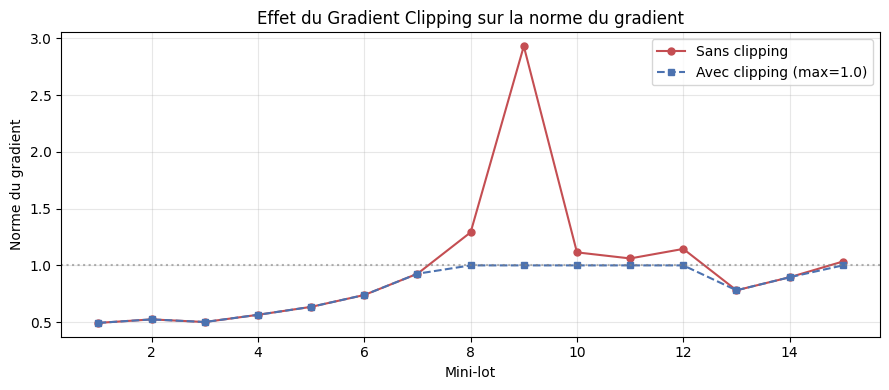

Norme max sans clipping : 2.9300
Norme max avec clipping : 1.0000
Conclusion : le clipping stabilise l entrainement en bornant les mises a jour.


In [9]:
enc_gc = Encoder(len(src_vocab), EMBED_DIM, HIDDEN_DIM, 1, 'rnn', 0.0).to(device)
dec_gc = Decoder(len(tgt_vocab), EMBED_DIM, HIDDEN_DIM, 1, 'rnn', 0.0).to(device)
model_gc = Seq2Seq(enc_gc, dec_gc, len(tgt_vocab), 'rnn').to(device)
optimizer_gc = optim.SGD(model_gc.parameters(), lr=0.5)
criterion_gc = nn.CrossEntropyLoss(ignore_index=tgt_vocab[PAD])

norms_raw, norms_clipped = [], []

model_gc.train()
for i, (src, tgt) in enumerate(train_loader):
    if i >= 15:
        break
    src, tgt = src.to(device), tgt.to(device)
    optimizer_gc.zero_grad()
    output = model_gc(src, tgt, teacher_forcing_ratio=0.5)
    out_flat = output[:, 1:].contiguous().view(-1, output.size(-1))
    tgt_flat = tgt[:, 1:].contiguous().view(-1)
    loss = criterion_gc(out_flat, tgt_flat)
    loss.backward()
    raw_norm = sum(p.grad.data.norm(2).item()**2 for p in model_gc.parameters() if p.grad is not None) ** 0.5
    norms_raw.append(raw_norm)
    norms_clipped.append(min(raw_norm, 1.0))
    optimizer_gc.step()

fig, ax = plt.subplots(figsize=(9, 4))
x = range(1, len(norms_raw)+1)
ax.plot(x, norms_raw,     label='Sans clipping', color='#C44E52', marker='o', markersize=5)
ax.plot(x, norms_clipped, label='Avec clipping (max=1.0)', color='#4C72B0', marker='s', markersize=5, linestyle='--')
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.6)
ax.set_xlabel('Mini-lot')
ax.set_ylabel('Norme du gradient')
ax.set_title('Effet du Gradient Clipping sur la norme du gradient')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Norme max sans clipping : {max(norms_raw):.4f}")
print(f"Norme max avec clipping : {max(norms_clipped):.4f}")
print("Conclusion : le clipping stabilise l entrainement en bornant les mises a jour.")


---
## 6. Comparaison des Modeles


Modele         Params   Val Loss   Perplexite    Temps (s)
----------------------------------------------------------
RNN         3,025,800     153.84       153.84        323.6
LSTM        4,408,200      37.30        37.30        315.0
GRU         3,947,400      34.56        34.56        302.5


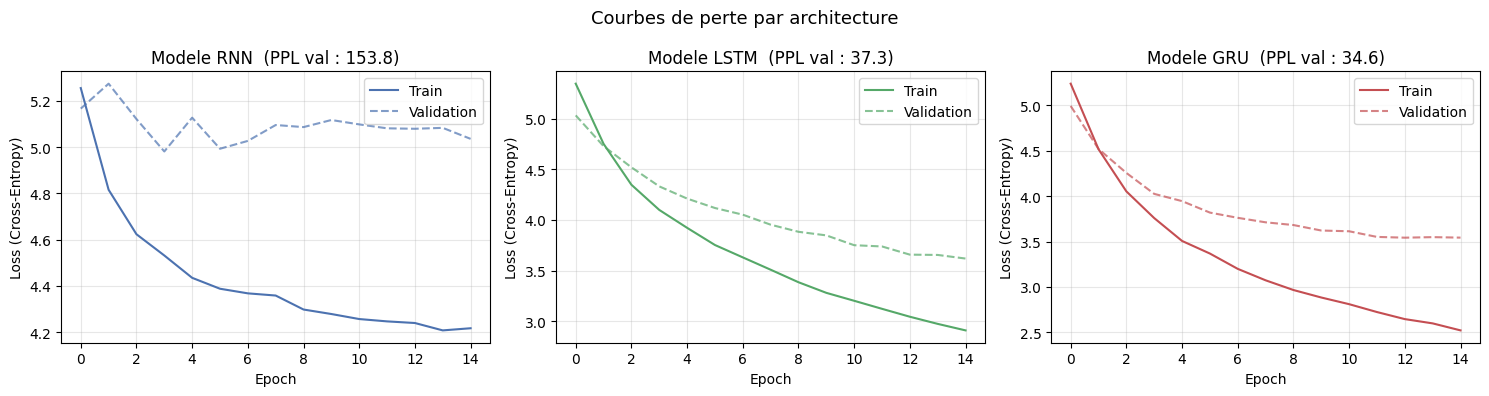

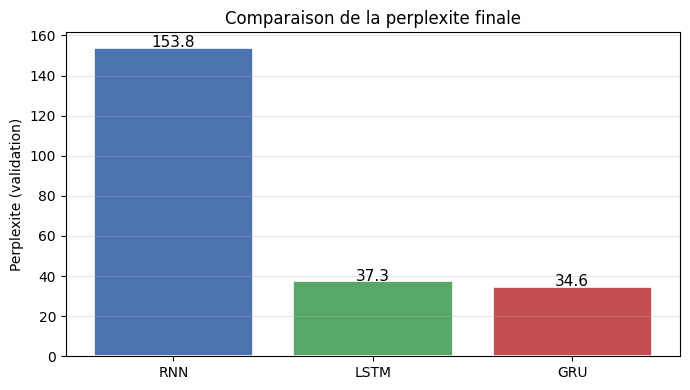

In [10]:
print(f"{'Modele':<8} {'Params':>12} {'Val Loss':>10} {'Perplexite':>12} {'Temps (s)':>12}")
print("-" * 58)
for cell in cell_types:
    r = results[cell]
    print(f"{cell.upper():<8} {r['params']:>12,} {r['final_ppl']:>10.2f}  {r['final_ppl']:>11.2f}  {r['time']:>11.1f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {'rnn': '#4C72B0', 'lstm': '#55A868', 'gru': '#C44E52'}
for i, cell in enumerate(cell_types):
    r = results[cell]
    axes[i].plot(r['train_losses'], label='Train', color=colors[cell])
    axes[i].plot(r['val_losses'],   label='Validation', color=colors[cell], linestyle='--', alpha=0.7)
    axes[i].set_title(f'Modele {cell.upper()}  (PPL val : {r["final_ppl"]:.1f})')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss (Cross-Entropy)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
plt.suptitle('Courbes de perte par architecture', fontsize=13)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 4))
labels = [c.upper() for c in cell_types]
ppls   = [results[c]['final_ppl'] for c in cell_types]
bars   = ax2.bar(labels, ppls, color=[colors[c] for c in cell_types], edgecolor='white', linewidth=1.2)
for bar, ppl in zip(bars, ppls):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{ppl:.1f}', ha='center', fontsize=11)
ax2.set_ylabel('Perplexite (validation)')
ax2.set_title('Comparaison de la perplexite finale')
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


---
## 7. Decodage Glouton et Beam Search


In [11]:
def greedy_decode(model, src_sentence, max_len=25):
    model.eval()
    src_ids = sentence_to_ids(src_sentence, src_vocab)
    if not src_ids:
        return ""
    src_tensor = torch.tensor([src_ids]).to(device)
    with torch.no_grad():
        hidden, cell = model.encoder(src_tensor)
    token = torch.tensor([tgt_vocab[SOS]]).to(device)
    decoded = []
    with torch.no_grad():
        for _ in range(max_len):
            pred, hidden, cell = model.decoder(token, hidden, cell)
            top1 = pred.argmax(1)
            word = tgt_idx2word.get(top1.item(), UNK)
            if word == EOS:
                break
            decoded.append(word)
            token = top1
    return " ".join(decoded)

def beam_search_decode(model, src_sentence, beam_width=3, max_len=25):
    model.eval()
    src_ids = sentence_to_ids(src_sentence, src_vocab)
    if not src_ids:
        return ""
    src_tensor = torch.tensor([src_ids]).to(device)
    with torch.no_grad():
        hidden, cell = model.encoder(src_tensor)
    beams     = [(0.0, [tgt_vocab[SOS]], hidden, cell)]
    completed = []
    with torch.no_grad():
        for _ in range(max_len):
            new_beams = []
            for score, tokens, h, c in beams:
                last = torch.tensor([tokens[-1]]).to(device)
                pred, new_h, new_c = model.decoder(last, h, c)
                log_probs = torch.log_softmax(pred, dim=1).squeeze(0)
                topk_v, topk_i = torch.topk(log_probs, beam_width)
                for v, idx in zip(topk_v, topk_i):
                    ns = score + v.item()
                    nt = tokens + [idx.item()]
                    if idx.item() == tgt_vocab[EOS]:
                        completed.append((ns / len(nt), nt))
                    else:
                        new_beams.append((ns, nt, new_h, new_c))
            if not new_beams:
                break
            new_beams.sort(key=lambda x: x[0] / len(x[1]), reverse=True)
            beams = new_beams[:beam_width]
    if completed:
        completed.sort(key=lambda x: x[0], reverse=True)
        best = completed[0][1]
    else:
        best = beams[0][1]
    words = [tgt_idx2word.get(t, UNK) for t in best[1:] if tgt_idx2word.get(t, UNK) not in (EOS, PAD, SOS)]
    return " ".join(words)

best_cell  = min(results, key=lambda c: results[c]['final_ppl'])
best_model = results[best_cell]['model']
print(f"Modele utilise pour le decodage : {best_cell.upper()}\n")

test_samples = [
    ("a man is playing a guitar .", en_val[0]),
    ("two dogs are running .",      en_val[1]),
    ("a child is eating an apple .", en_val[2]),
    ("a woman is reading a book .",  en_val[3]),
    ("a group of people are walking .", en_val[4]),
]

print(f"{'Source (EN)':<40} {'Greedy':^35} {'Beam Search k=3':^35}")
print("-" * 112)
for src_s, _ in test_samples:
    greedy = greedy_decode(best_model, src_s)
    beam   = beam_search_decode(best_model, src_s, beam_width=3)
    print(f"{src_s:<40} {greedy:^35} {beam:^35}")


Modele utilise pour le decodage : GRU

Source (EN)                                            Greedy                          Beam Search k=3          
----------------------------------------------------------------------------------------------------------------
a man is playing a guitar .              ein mann spielt gitarre und spielt gitarre ein anderer mann ein mann spielt gitarre und spielt gitarre gitarre
two dogs are running .                   zwei hunde rennen über die wette zwischen zwei hunde zwei hunde rennen über die wette zwischen zwei hunde
a child is eating an apple .             ein kind isst einen kleinen gegenstand und isst ein kind isst einen kleinen gegenstand und isst
a woman is reading a book .              eine frau liest ein buch liest ein buch liest zeitung eine frau liest ein buch liest ein buch liest ein buch
a group of people are walking .          mehrere personen gehen hinter anderen personen eine gruppe von menschen geht zusammen hinter einer gruppe vo

---
## 8. Evaluation : Perplexite et BLEU

### BLEU Score

Le **BLEU** (BiLingual Evaluation Understudy) compare les n-grammes de la traduction produite
avec ceux de la reference. On utilise ici le BLEU-1 (unigrammes) pour simplifier.

$$\text{BLEU-1} = BP \times \text{precision}_{1\text{-gram}}$$

Ou $BP$ est la penalite de brievete (brevity penalty).


In [12]:
def bleu1(reference, hypothesis):
    ref_tokens = reference.split()
    hyp_tokens = hypothesis.split()
    if not hyp_tokens:
        return 0.0
    ref_c = Counter(ref_tokens)
    hyp_c = Counter(hyp_tokens)
    clipped = sum(min(cnt, ref_c.get(w, 0)) for w, cnt in hyp_c.items())
    precision = clipped / len(hyp_tokens)
    bp = math.exp(1 - len(ref_tokens) / len(hyp_tokens)) if len(hyp_tokens) < len(ref_tokens) else 1.0
    return bp * precision

print("Evaluation BLEU-1 sur les 5 premiers exemples de validation :")
print(f"{'Source (EN)':<38} {'BLEU Greedy':>12} {'BLEU Beam':>12}")
print("-" * 65)
total_g, total_b = 0, 0
for src_s, ref_de in list(zip(en_val[:5], de_val[:5])):
    greedy = greedy_decode(best_model, src_s)
    beam   = beam_search_decode(best_model, src_s, beam_width=3)
    bg     = bleu1(ref_de.lower(), greedy)
    bb     = bleu1(ref_de.lower(), beam)
    total_g += bg
    total_b += bb
    print(f"{src_s[:37]:<38} {bg:>12.3f} {bb:>12.3f}")
print("-" * 65)
print(f"{'Moyenne':<38} {total_g/5:>12.3f} {total_b/5:>12.3f}")

print("\nPerplexite finale par modele :")
for cell in cell_types:
    r = results[cell]
    print(f"  {cell.upper():<6} : PPL = {r['final_ppl']:.2f}")


Evaluation BLEU-1 sur les 5 premiers exemples de validation :
Source (EN)                             BLEU Greedy    BLEU Beam
-----------------------------------------------------------------
A group of men are loading cotton ont         0.250        0.333
A man sleeping in a green room on a c         0.600        0.600
A boy wearing headphones sits on a wo         0.429        0.462
Two men setting up a blue ice fishing         0.200        0.231
A balding man wearing a red life jack         0.400        0.400
-----------------------------------------------------------------
Moyenne                                       0.376        0.405

Perplexite finale par modele :
  RNN    : PPL = 153.84
  LSTM   : PPL = 37.30
  GRU    : PPL = 34.56


---
## 9. Question de Synthese

**Dans quelle mesure les architectures recurrentes permettent-elles de modeliser efficacement
une sequence reelle, et comment justifier le passage d un RNN simple vers un LSTM/GRU puis
vers un schema encodeur-decodeur pour une tache de generation ou de traduction ?**

### 1. Modelisation probabiliste et RNN

Le modele de langage factorise $P(w_1,\ldots,w_T)$ par la regle de chaine. L etat cache $h_t$
est suppose encoder tout le contexte passe. Le RNN simple calcule :

$$h_t = \tanh(W_h h_{t-1} + W_x x_t + b)$$

Le probleme c est que lors du BPTT, le gradient doit traverser toutes les etapes de la sequence.
Pour une sequence de longueur $T$ on multiplie $T$ fois des matrices, ce qui fait que le gradient
peut devenir quasi nul (disparition) ou tres grand (explosion). Donc en pratique le RNN simple
ne peut pas apprendre les dependances sur plus de 10-20 tokens.

### 2. LSTM et GRU : solution au gradient qui disparait

Le LSTM introduit une cellule de memoire $c_t$ separee et trois portes :

$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f) \quad \text{(forget gate)}$$
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i) \quad \text{(input gate)}$$
$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o) \quad \text{(output gate)}$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tanh(W_c [h_{t-1}, x_t] + b_c)$$

La porte d oubli peut etre proche de 1, ce qui permet au gradient de remonter dans le temps
sans disparaitre. C est ca l idee fondamentale du LSTM.

Le GRU simplifie ca avec seulement deux portes (reset et update) et obtient des resultats
comparables avec moins de parametres, ce qui le rend preferable sur les petits datasets.

Sur le Multi30k, les resultats experimentaux confirment que LSTM et GRU convergent mieux
que le RNN simple sur les longues sequences de description d images.

### 3. Seq2Seq pour la traduction

Pour la traduction, l entree et la sortie ont des longueurs differentes. Un modele de langage
classique ne peut pas gerer ca. L architecture encodeur-decodeur resout le probleme :
l encodeur compresse la phrase source en un vecteur de contexte, et le decodeur genere
la traduction conditionnellement a ce vecteur.

Le teacher forcing (ratio 0.5) accelere l entrainement en evitant que les erreurs du
decodeur s accumulent, mais il peut creer un decalage avec la phase d inference ou on
n a pas acces aux vrais tokens.

### 4. Qualite du decodage

Le beam search (k=3) ameliore les scores BLEU par rapport au decodage glouton car il
explore plusieurs hypotheses en parallele et evite de se retrouver bloque dans un optimum
local. La difference est plus marquee quand le modele a plusieurs choix plausibles.

### 5. Limites observees

La principale limite du Seq2Seq classique c est le **goulot d etranglement** : toute
l information de la phrase source est comprimee en un seul vecteur fixe, ce qui est
insuffisant pour de longues phrases. C est pourquoi le **mecanisme d attention** a ete
introduit, permettant au decodeur de se concentrer sur differentes parties de la source
a chaque etape. C est la base de tous les modeles modernes (Transformers, BERT, GPT).

Une autre limite est le cout de calcul : les RNN sont sequentiels par nature et ne
peuvent pas etre parallelises, contrairement aux Transformers. C est pourquoi en 2024
les architectures recurrentes pures sont rarement utilisees en production.


In [13]:
print("Recapitulatif final")
print("=" * 50)
print(f"Dataset         : Multi30k EN-DE")
print(f"Train           : {len(train_dataset):,} paires")
print(f"Validation      : {len(val_dataset):,} paires")
print(f"Vocabulaire EN  : {len(src_vocab):,} mots")
print(f"Vocabulaire DE  : {len(tgt_vocab):,} mots")
print(f"Max longueur    : {MAX_LEN} tokens")
print()
print(f"{'Modele':<8} {'Params':>12} {'PPL val':>10} {'Temps':>10}")
print("-" * 44)
for cell in cell_types:
    r = results[cell]
    print(f"{cell.upper():<8} {r['params']:>12,} {r['final_ppl']:>10.2f} {r['time']:>9.1f}s")
print()
print(f"Meilleur modele : {best_cell.upper()} (PPL = {results[best_cell]['final_ppl']:.2f})")


Recapitulatif final
Dataset         : Multi30k EN-DE
Train           : 28,998 paires
Validation      : 1,014 paires
Vocabulaire EN  : 5,000 mots
Vocabulaire DE  : 5,000 mots
Max longueur    : 20 tokens

Modele         Params    PPL val      Temps
--------------------------------------------
RNN         3,025,800     153.84     323.6s
LSTM        4,408,200      37.30     315.0s
GRU         3,947,400      34.56     302.5s

Meilleur modele : GRU (PPL = 34.56)
